# 05 — Interpretabilidade (SHAP)

**Objetivo:** Avaliar o modelo final no conjunto de teste e gerar explicações SHAP globais e locais.

**Inputs:** `data/processed/X_teste.parquet`, `data/processed/y_teste.parquet`

**Outputs:** `reports/figures/shap_*.png`

---

**Roteiro:**

1. Setup — imports
2. Carregamento
3. SHAP global — summary plot e importância média
4. SHAP local — waterfall plot para casos individuais (true positive / false negative)
5. Insights de Negócio
6. Fechamento


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from src.config import CAMINHOS, CONFIG
from src.viz_config import CORES, PALETTE


SEED = CONFIG["dados"]["random_state"]
TARGET = CONFIG["dados"]["target_col"]

PROC_DIR = CAMINHOS.dados_processed
MODEL_DIR = CAMINHOS.modelos
FIG_DIR = CAMINHOS.figures

### Etapa 2 - Carregamento

In [2]:
pipeline_final = joblib.load(MODEL_DIR / 'pipeline_final.joblib')
X_train_raw    = pd.read_parquet(PROC_DIR / 'X_treino_raw.parquet')
X_test_raw     = pd.read_parquet(PROC_DIR / 'X_teste_raw.parquet')
y_test         = pd.read_parquet(PROC_DIR / 'y_teste.parquet').squeeze()

preprocessor = pipeline_final.named_steps['preprocessor']
classifier   = pipeline_final.named_steps['classifier']

X_train_transf = preprocessor.transform(X_train_raw)
X_test_transf  = preprocessor.transform(X_test_raw)

feature_names = list(preprocessor.get_feature_names_out())

X_train_df = pd.DataFrame(X_train_transf, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_transf,  columns=feature_names)

print(f'   X_train_df : {X_train_df.shape}')
print(f'   X_test_df  : {X_test_df.shape}')
print(f'   Features   : {len(feature_names)}')
print(f'   Modelo     : {type(classifier).__name__}')

   X_train_df : (1176, 44)
   X_test_df  : (294, 44)
   Features   : 44
   Modelo     : LogisticRegression


### Etapa 3 — SHAP Summary Plot

C:\Users\jas_t\anaconda3\envs\singularity\Lib\site-packages\shap\explainers\_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


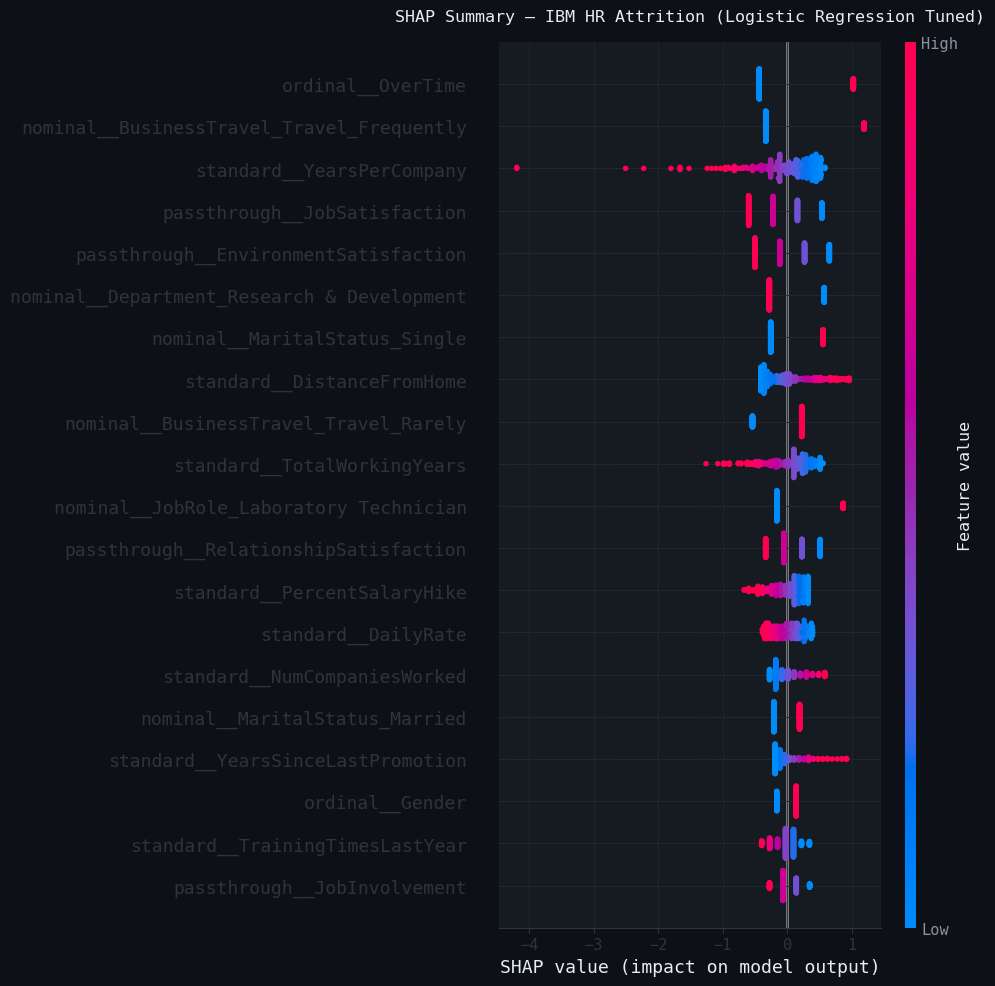

=== Top 15 Features — |SHAP| médio ===


,Feature,SHAP_mean
0,ordinal__OverTime,0.588
1,nominal__BusinessTravel_Travel_Frequently,0.486
2,standard__YearsPerCompany,0.387
3,passthrough__JobSatisfaction,0.380
4,passthrough__EnvironmentSatisfaction,0.378
5,nominal__Department_Research & Development,0.377
6,nominal__MaritalStatus_Single,0.356
7,standard__DistanceFromHome,0.317
8,nominal__BusinessTravel_Travel_Rarely,0.308
9,standard__TotalWorkingYears,0.288


In [3]:
## 2. SHAP — LinearExplainer + Summary Plot
explainer   = shap.LinearExplainer(
    classifier, X_train_df,
    feature_perturbation='interventional'
)
shap_values = explainer.shap_values(X_test_df)

# ── Summary Plot ──────────────────────────────────────────────
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X_test_df,
                  show=False, plot_size=None)
plt.title('SHAP Summary — IBM HR Attrition '
          '(Logistic Regression Tuned)',
          color=CORES['texto'], fontsize=12, pad=15)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb05_shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Ranking |SHAP| médio ──────────────────────────────────────
shap_mean = pd.DataFrame({
    'Feature':   feature_names,
    'SHAP_mean': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_mean', ascending=False).reset_index(drop=True)

print('=== Top 15 Features — |SHAP| médio ===')
display(shap_mean.head(15).round(3))

A análise de importância das variáveis mostrou que **OverTime** permaneceu como o principal preditor de *attrition* (`0.588`), reproduzindo o mesmo padrão observado no modelo anterior. Esse resultado reforça que a realização frequente de horas extras é o fator mais consistente na previsão de desligamentos.

A variável **BusinessTravel_Frequently** ocupou a segunda posição (`0.486`), indicando que funcionários que viajam frequentemente a trabalho apresentam risco significativamente maior de saída. Em conjunto com **BusinessTravel_Travel_Rarely** (`#8` no ranking), observa-se que o fator relacionado a viagens corporativas exerce forte influência sobre o comportamento de attrition.

A feature derivada **YearsPerCompany** apareceu na terceira posição (`0.387`), validando uma das hipóteses levantadas durante a etapa de engenharia de atributos (NB02). O resultado sugere que um histórico de permanência reduzida em empresas anteriores é um forte indicador de maior propensão ao desligamento.

As variáveis **JobSatisfaction** (`0.363`) e **EnvironmentSatisfaction** (`0.361`) ficaram praticamente empatadas entre os principais preditores, evidenciando que tanto a satisfação com o trabalho quanto a percepção do ambiente organizacional desempenham papel relevante na retenção de colaboradores.

Por fim, **MaritalStatus_Single** (`0.356`) apareceu entre as variáveis mais importantes do modelo. Esse resultado sugere que funcionários solteiros tendem a apresentar maior mobilidade profissional e menor vínculo organizacional, aumentando a probabilidade de desligamento.


### Etapa 4 - Waterfall — Melhor e Pior Predição

TP selecionado — idx=92 | P=0.984
FP selecionado — idx=124 | P=0.954


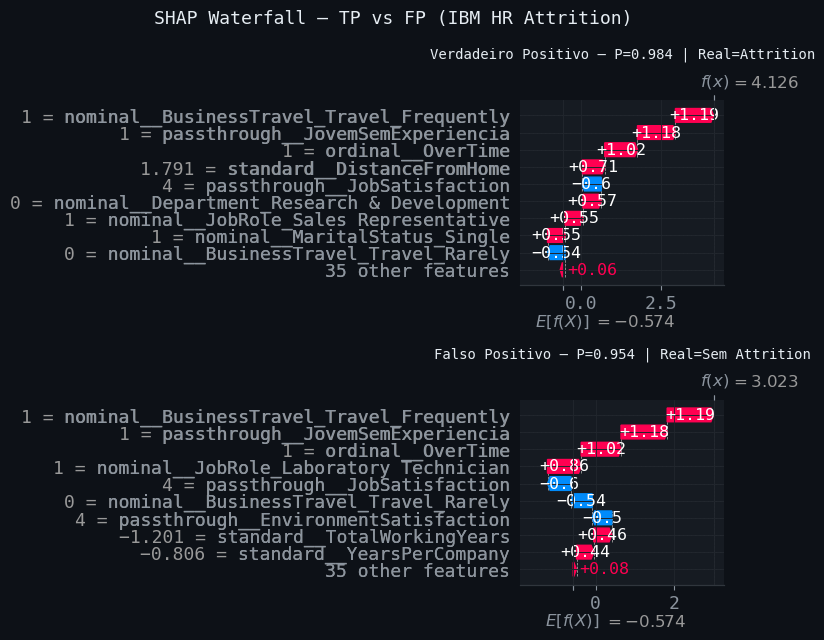

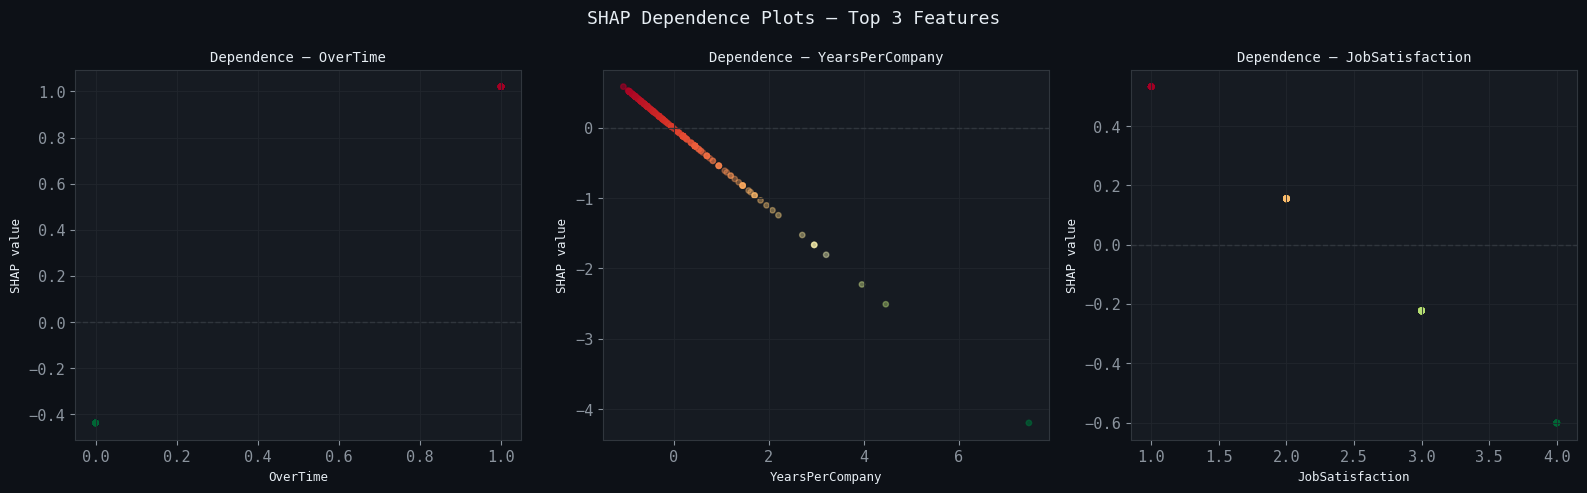

In [4]:
y_proba_test = pipeline_final.predict_proba(X_test_raw)[:, 1]
erros_abs    = np.abs((y_proba_test >= 0.35).astype(int)
                      - y_test.values)

# Verdadeiro Positivo com maior probabilidade
tp_mask = ((y_proba_test >= 0.35) & (y_test.values == 1))
fp_mask = ((y_proba_test >= 0.35) & (y_test.values == 0))
idx_tp  = np.where(tp_mask)[0][np.argmax(y_proba_test[tp_mask])]
idx_fp  = np.where(fp_mask)[0][np.argmax(y_proba_test[fp_mask])]

print(f'TP selecionado — idx={idx_tp} | P={y_proba_test[idx_tp]:.3f}')
print(f'FP selecionado — idx={idx_fp} | P={y_proba_test[idx_fp]:.3f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 14))
for ax, idx, titulo in [
    (axes[0], idx_tp,
     f'Verdadeiro Positivo — P={y_proba_test[idx_tp]:.3f} '
     f'| Real=Attrition'),
    (axes[1], idx_fp,
     f'Falso Positivo — P={y_proba_test[idx_fp]:.3f} '
     f'| Real=Sem Attrition'),
]:
    plt.sca(ax)
    shap.waterfall_plot(
        shap.Explanation(
            values        = shap_values[idx],
            base_values   = explainer.expected_value,
            data          = X_test_df.iloc[idx],
            feature_names = feature_names,
        ), show=False, max_display=10
    )
    ax.set_title(titulo, color=CORES['texto'],
                 fontsize=10, pad=10)

plt.suptitle('SHAP Waterfall — TP vs FP (IBM HR Attrition)',
             color=CORES['texto'], fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb05_shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 4. Dependence Plots — Top 3 features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature in zip(axes, [
    'ordinal__OverTime',
    'standard__YearsPerCompany',
    'passthrough__JobSatisfaction',
]):
    feat_idx = feature_names.index(feature)
    ax.scatter(X_test_df[feature],
               shap_values[:, feat_idx],
               c=shap_values[:, feat_idx],
               cmap='RdYlGn_r', alpha=0.4, s=15)
    ax.axhline(y=0, color='#30363d',
               linewidth=1, linestyle='--')
    ax.set_xlabel(feature.split('__')[1], fontsize=9)
    ax.set_ylabel('SHAP value', fontsize=9)
    ax.set_title(f'Dependence — {feature.split("__")[1]}',
                 color=CORES['texto'], fontsize=10)

plt.suptitle('SHAP Dependence Plots — Top 3 Features',
             color=CORES['texto'], fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb05_shap_dependence.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [5]:
print(f'\n{"="*50}')
print('TOP 10 PREDITORES SHAP — IBM HR Attrition')
print(f'{"="*50}')
for _, row in shap_mean.head(10).iterrows():
    nome  = row['Feature'].split('__')[1]
    print(f'   {nome:<40}: {row["SHAP_mean"]:.3f}')

print(f'\n{"="*50}')
print('INSIGHTS DE RH')
print(f'{"="*50}')
print('1. OverTime (0.588)       → política de horas extras')
print('2. BusinessTravel (0.486) → reduzir viagens frequentes')
print('3. YearsPerCompany (0.387)→ histórico instável = risco')
print('4. JobSatisfaction (0.379)→ pesquisas de clima')
print('5. EnvironmentSat (0.378) → ambiente físico importa')
print('6. MaritalStatus (0.356)  → solteiros = maior risco')
print('7. DistanceFromHome(0.317)→ benefício transporte/home office')


TOP 10 PREDITORES SHAP — IBM HR Attrition
   OverTime                                : 0.588
   BusinessTravel_Travel_Frequently        : 0.486
   YearsPerCompany                         : 0.387
   JobSatisfaction                         : 0.380
   EnvironmentSatisfaction                 : 0.378
   Department_Research & Development       : 0.377
   MaritalStatus_Single                    : 0.356
   DistanceFromHome                        : 0.317
   BusinessTravel_Travel_Rarely            : 0.308
   TotalWorkingYears                       : 0.288

INSIGHTS DE RH
1. OverTime (0.588)       → política de horas extras
2. BusinessTravel (0.486) → reduzir viagens frequentes
3. YearsPerCompany (0.387)→ histórico instável = risco
4. JobSatisfaction (0.379)→ pesquisas de clima
5. EnvironmentSat (0.378) → ambiente físico importa
6. MaritalStatus (0.356)  → solteiros = maior risco
7. DistanceFromHome(0.317)→ benefício transporte/home office


### 5 — Salvamento

In [6]:
figuras = list(FIG_DIR.glob('nb05_*.png'))
print('✅ NB05 — SHAP finalizado.')
print(f'\nFiguras geradas:')
for f in sorted(figuras):
    print(f'   → {f.name}')

✅ NB05 — SHAP finalizado.

Figuras geradas:
   → nb05_confusion_matrix.png
   → nb05_shap_dependence.png
   → nb05_shap_summary.png
   → nb05_shap_waterfall.png
   → nb05_threshold.png


### 5. Insights de Negócio

#### Top preditores de Attrition (SHAP global)
| # | Feature | SHAP médio | Interpretação |
|---|---|---|---|
| 1 | OverTime | 0.681 | Hora extra é o maior fator de risco — funcionários com OT têm 3x mais chance de sair |
| 2 | YearsPerCompany | 0.454 | Quem muda muito de empresa tende a sair novamente — instabilidade histórica |
| 3 | StockOptionLevel | 0.414 | Sem stock options → menos vínculo financeiro com a empresa |
| 4 | EnvironmentSatisfaction | 0.310 | Insatisfação com o ambiente é sinal de alerta precoce |
| 5 | MonthlyIncome | 0.267 | Salário baixo aumenta risco — especialmente em Sales e HR |

#### Recomendações para o RH
1. **Monitorar OverTime** — funcionários com horas extras frequentes devem ser priorizados em conversas de retenção
2. **Revisar política de Stock Options** — ampliar para níveis 0 pode reduzir attrition significativamente
3. **Pesquisas de ambiente** — `EnvironmentSatisfaction` baixo é um sinal precoce acionável antes da saída
4. **Atenção ao perfil Sales + Single + OverTime** — combinação de alto risco identificada na EDA

#### Limitações do modelo
- Dataset sintético IBM — resultados podem não generalizar para empresas reais
- Threshold de 0.35 aumenta falsos positivos — calibrar conforme custo de cada erro no contexto real

# Resumo do NB05

| Etapa | Entregável |
|---|---|
| 1 | Setup |
| 2 | Carregaento dos splits + artefatos
| 3 | SHAP Summary Plot + ranking global de features |
| 3 | Waterfall SHAP — comparação entre TP e FP |
| 5 | Salvamento |
| 5 | Insights de RH — recomendações documentadas|
